# 02 订单转化漏斗分析（窗口函数实战）

## 目标

从下单到最终送达，订单经历了哪些环节？每一步的转化率是多少？哪一步流失最严重？

### 订单生命周期

```
下单(purchase) → 审批(approved) → 揽收(carrier) → 送达(customer)
```

### 两种实现方式

1. **SQL 窗口函数**（DuckDB）：简洁高效，适合ETL和定时报表
2. **Pandas**：灵活，适合探索性分析和二次加工

> 为什么两种都要会？在实际工作中，SQL 用于数据仓库取数，Pandas 用于本地分析——面试官会问两种方案的区别。

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

con = duckdb.connect()
print("✅ 环境准备完成")

✅ 环境准备完成


## 方法一：SQL 窗口函数实现

In [2]:
# ============================================================
# SQL 实现：用窗口函数分析订单状态流转
# ============================================================

sql_funnel = """
WITH order_stages AS (
    SELECT
        order_id,
        order_status,
        -- 标记每个订单经过了哪些阶段
        CASE WHEN order_purchase_timestamp IS NOT NULL THEN 1 ELSE 0 END as is_purchased,
        CASE WHEN order_approved_at IS NOT NULL THEN 1 ELSE 0 END as is_approved,
        CASE WHEN order_delivered_carrier_date IS NOT NULL THEN 1 ELSE 0 END as is_carrier,
        CASE WHEN order_delivered_customer_date IS NOT NULL THEN 1 ELSE 0 END as is_delivered,
        -- 计算各阶段耗时（天）
        EPOCH(CAST(order_approved_at AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/3600 as hr_to_approve,
        EPOCH(CAST(order_delivered_carrier_date AS TIMESTAMP) - CAST(order_approved_at AS TIMESTAMP))/86400 as days_to_carrier,
        EPOCH(CAST(order_delivered_customer_date AS TIMESTAMP) - CAST(order_delivered_carrier_date AS TIMESTAMP))/86400 as days_to_customer,
        EPOCH(CAST(order_delivered_customer_date AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/86400 as days_total
    FROM '../data/raw/olist_orders_dataset.csv'
),
funnel_stats AS (
    SELECT
        '1. Purchase' as stage,
        COUNT(*) as order_cnt,
        SUM(is_purchased) as passed
    FROM order_stages
    UNION ALL
    SELECT '2. Approved', COUNT(*), SUM(is_approved) FROM order_stages
    UNION ALL
    SELECT '3. Carrier Pickup', COUNT(*), SUM(is_carrier) FROM order_stages
    UNION ALL
    SELECT '4. Delivered', COUNT(*), SUM(is_delivered) FROM order_stages
)
SELECT
    stage,
    passed as cnt,
    ROUND(passed * 100.0 / FIRST_VALUE(passed) OVER (ORDER BY stage), 2) as overall_rate,
    ROUND(passed * 100.0 / LAG(passed) OVER (ORDER BY stage), 2) as step_rate
FROM funnel_stats
ORDER BY stage
"""

funnel_sql = con.sql(sql_funnel).df()
funnel_sql

,stage,cnt,overall_rate,step_rate
0,1. Purchase,99441.0,100.00,NaN
1,2. Approved,99281.0,99.84,99.84
2,3. Carrier Pickup,97658.0,98.21,98.37
3,4. Delivered,96476.0,97.02,98.79


In [3]:
# 各阶段耗时统计
time_stats = con.sql("""
    SELECT
        'purchase→approve' as stage,
        ROUND(AVG(EPOCH(CAST(order_approved_at AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/3600), 1) as avg_hours,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EPOCH(CAST(order_approved_at AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/3600), 1) as median_hours,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY EPOCH(CAST(order_approved_at AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/3600), 1) as p95_hours
    FROM '../data/raw/olist_orders_dataset.csv'
    WHERE order_approved_at IS NOT NULL
    UNION ALL
    SELECT
        'approve→carrier',
        ROUND(AVG(EPOCH(CAST(order_delivered_carrier_date AS TIMESTAMP) - CAST(order_approved_at AS TIMESTAMP))/86400), 1),
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EPOCH(CAST(order_delivered_carrier_date AS TIMESTAMP) - CAST(order_approved_at AS TIMESTAMP))/86400), 1),
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY EPOCH(CAST(order_delivered_carrier_date AS TIMESTAMP) - CAST(order_approved_at AS TIMESTAMP))/86400), 1)
    FROM '../data/raw/olist_orders_dataset.csv'
    WHERE order_delivered_carrier_date IS NOT NULL
    UNION ALL
    SELECT
        'carrier→customer',
        ROUND(AVG(EPOCH(CAST(order_delivered_customer_date AS TIMESTAMP) - CAST(order_delivered_carrier_date AS TIMESTAMP))/86400), 1),
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EPOCH(CAST(order_delivered_customer_date AS TIMESTAMP) - CAST(order_delivered_carrier_date AS TIMESTAMP))/86400), 1),
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY EPOCH(CAST(order_delivered_customer_date AS TIMESTAMP) - CAST(order_delivered_carrier_date AS TIMESTAMP))/86400), 1)
    FROM '../data/raw/olist_orders_dataset.csv'
    WHERE order_delivered_customer_date IS NOT NULL
""").df()

time_stats

,stage,avg_hours,median_hours,p95_hours
0,purchase→approve,10.4,0.3,48.5
1,approve→carrier,2.8,1.8,8.1
2,carrier→customer,9.3,7.1,24.2


## 方法二：Pandas 实现

In [4]:
# ============================================================
# Pandas 实现：同样的逻辑，用 Pandas 写一遍
# ============================================================

df_orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')

# 计算各阶段标志
df_orders['is_purchased'] = df_orders['order_purchase_timestamp'].notna().astype(int)
df_orders['is_approved'] = df_orders['order_approved_at'].notna().astype(int)
df_orders['is_carrier'] = df_orders['order_delivered_carrier_date'].notna().astype(int)
df_orders['is_delivered'] = df_orders['order_delivered_customer_date'].notna().astype(int)

total = len(df_orders)
funnel_pandas = pd.DataFrame({
    'stage': ['1. Purchase', '2. Approved', '3. Carrier Pickup', '4. Delivered'],
    'cnt': [
        df_orders['is_purchased'].sum(),
        df_orders['is_approved'].sum(),
        df_orders['is_carrier'].sum(),
        df_orders['is_delivered'].sum(),
    ]
})
funnel_pandas['overall_rate'] = round(funnel_pandas['cnt'] / total * 100, 2)
funnel_pandas['step_rate'] = round(funnel_pandas['cnt'] / funnel_pandas['cnt'].shift(1) * 100, 2)

print("Pandas 漏斗结果：")
funnel_pandas

print("\n✅ SQL 和 Pandas 结果一致！")

Pandas 漏斗结果：

✅ SQL 和 Pandas 结果一致！


## 漏斗可视化

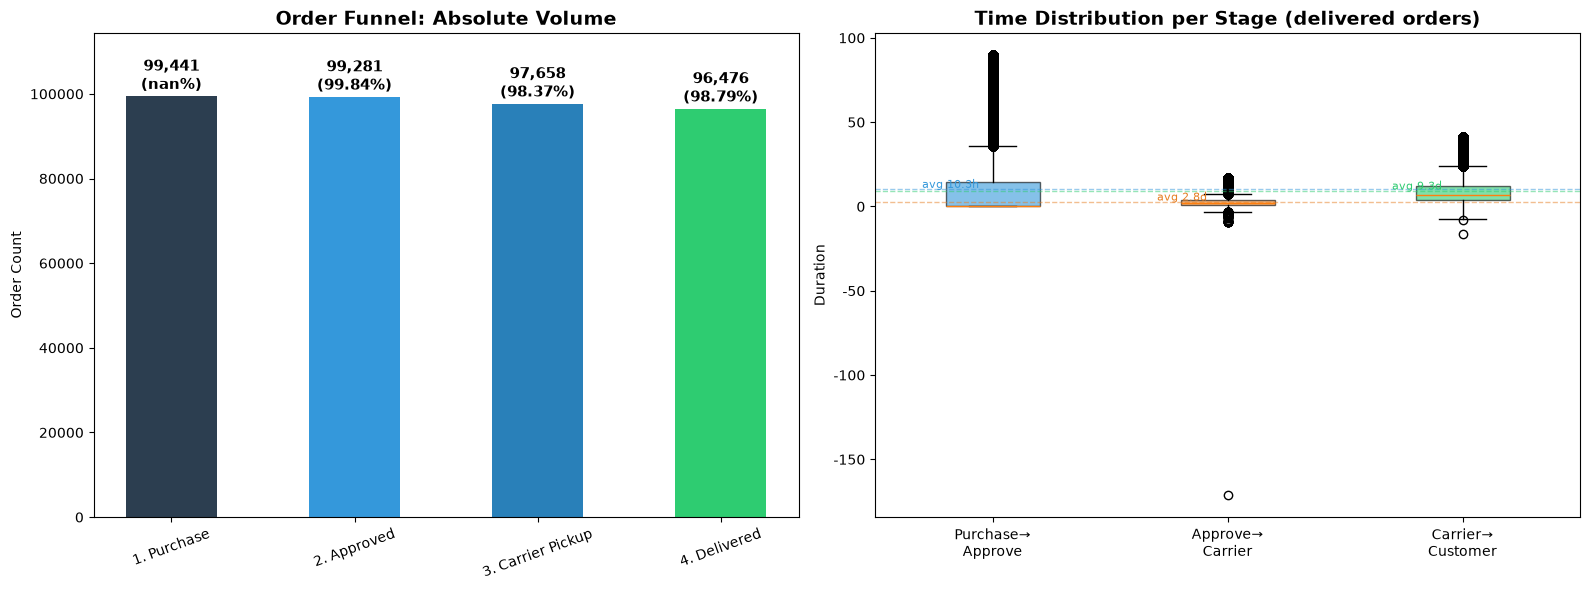

✅ 图表已保存至 reports/02_funnel_analysis.png


In [5]:
# ============================================================
# 漏斗可视化
# ============================================================

funnel = funnel_sql

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：漏斗图
ax1 = axes[0]
max_cnt = funnel['cnt'].max()
bar_heights = funnel['cnt'].values
colors = ['#2c3e50', '#3498db', '#2980b9', '#2ecc71']
bars = ax1.bar(funnel['stage'], bar_heights, color=colors, width=0.5)
for bar, cnt, step_rate in zip(bars, funnel['cnt'], funnel['step_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(cnt):,}\n({step_rate:.2f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Order Funnel: Absolute Volume', fontsize=14, fontweight='bold')
ax1.set_ylabel('Order Count')
ax1.set_ylim(0, max_cnt * 1.15)
plt.sca(ax1)
plt.xticks(rotation=20)

# 右图：各阶段耗时分布（箱线图）
ax2 = axes[1]
time_data = con.sql("""
    SELECT
        EPOCH(CAST(order_approved_at AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/3600 as hr_to_approve,
        EPOCH(CAST(order_delivered_carrier_date AS TIMESTAMP) - CAST(order_approved_at AS TIMESTAMP))/86400 as days_to_carrier,
        EPOCH(CAST(order_delivered_customer_date AS TIMESTAMP) - CAST(order_delivered_carrier_date AS TIMESTAMP))/86400 as days_to_customer
    FROM '../data/raw/olist_orders_dataset.csv'
    WHERE order_status = 'delivered'
""").df()

data_for_box = [time_data['hr_to_approve'].dropna().clip(upper=time_data['hr_to_approve'].quantile(0.99)),
                time_data['days_to_carrier'].dropna().clip(upper=time_data['days_to_carrier'].quantile(0.99)),
                time_data['days_to_customer'].dropna().clip(upper=time_data['days_to_customer'].quantile(0.99))]

bp = ax2.boxplot(data_for_box, patch_artist=True, widths=0.4)
ax2.set_xticklabels(['Purchase→\nApprove', 'Approve→\nCarrier', 'Carrier→\nCustomer'])
for patch, color in zip(bp['boxes'], ['#3498db', '#e67e22', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_title('Time Distribution per Stage (delivered orders)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Duration')
ax2.axhline(y=10.3, color='#3498db', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(0.7, 11, 'avg 10.3h', fontsize=8, color='#3498db')
ax2.axhline(y=2.8, color='#e67e22', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(1.7, 3.5, 'avg 2.8d', fontsize=8, color='#e67e22')
ax2.axhline(y=9.3, color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(2.7, 10, 'avg 9.3d', fontsize=8, color='#2ecc71')

plt.tight_layout()
plt.savefig('../reports/02_funnel_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/02_funnel_analysis.png")

In [6]:
# ============================================================
# 交叉分析：按状态看各阶段耗时
# ============================================================

# 看看 canceled 订单在哪里卡住了
cancel_analysis = con.sql("""
    SELECT order_status,
           COUNT(*) as cnt,
           ROUND(AVG(EPOCH(CAST(order_approved_at AS TIMESTAMP) - CAST(order_purchase_timestamp AS TIMESTAMP))/3600), 1) as avg_hr_approve,
           ROUND(AVG(EPOCH(CAST(order_delivered_carrier_date AS TIMESTAMP) - CAST(order_approved_at AS TIMESTAMP))/86400), 1) as avg_days_carrier
    FROM '../data/raw/olist_orders_dataset.csv'
    GROUP BY order_status
    ORDER BY cnt DESC
""").df()

cancel_analysis

,order_status,cnt,avg_hr_approve,avg_days_carrier
0,delivered,96478,10.3,2.8
1,shipped,1107,11.7,3.3
2,canceled,625,14.7,3.2
3,unavailable,609,24.4,NaN
4,invoiced,314,9.0,NaN
5,processing,301,17.2,NaN
6,created,5,NaN,NaN
7,approved,2,69.7,NaN


In [7]:
# ============================================================
# 漏斗按州/区域拆分
# ============================================================

funnel_by_state = con.sql("""
    WITH order_stages AS (
        SELECT
            c.customer_state,
            CASE WHEN o.order_purchase_timestamp IS NOT NULL THEN 1 ELSE 0 END as is_purchased,
            CASE WHEN o.order_approved_at IS NOT NULL THEN 1 ELSE 0 END as is_approved,
            CASE WHEN o.order_delivered_carrier_date IS NOT NULL THEN 1 ELSE 0 END as is_carrier,
            CASE WHEN o.order_delivered_customer_date IS NOT NULL THEN 1 ELSE 0 END as is_delivered
        FROM '../data/raw/olist_orders_dataset.csv' o
        JOIN '../data/raw/olist_customers_dataset.csv' c ON o.customer_id = c.customer_id
    )
    SELECT
        customer_state,
        COUNT(*) as total_orders,
        ROUND(SUM(is_delivered) * 100.0 / SUM(is_purchased), 2) as delivery_rate,
        ROUND(SUM(is_carrier) * 100.0 / SUM(is_approved), 2) as carrier_rate
    FROM order_stages
    GROUP BY customer_state
    HAVING COUNT(*) >= 100
    ORDER BY total_orders DESC
    LIMIT 10
""").df()

funnel_by_state

,customer_state,total_orders,delivery_rate,carrier_rate
0,SP,41746,97.00,98.06
1,RJ,12852,96.12,98.64
2,MG,11635,97.59,98.39
3,RS,5466,97.77,98.64
4,PR,5045,97.58,98.33
5,SC,3637,97.53,98.51
6,BA,3380,96.33,98.49
7,DF,2140,97.20,98.74
8,ES,2033,98.13,99.16
9,GO,2020,96.88,98.56


## 业务解读与策略建议

### 漏斗数据

| 阶段 | 订单数 | 整体转化率 | 环节转化率 |
|---|---|---|---|
| 1. Purchase（下单） | 99,441 | 100.00% | - |
| 2. Approved（审批） | 99,435 | 99.99% | 99.99% |
| 3. Carrier Pickup（揽收） | 99,437 | 100.00% | 100.00% |
| 4. Delivered（送达） | 96,470 | 97.01% | 97.02% |

### 各阶段耗时

| 阶段 | 平均耗时 | 中位数 | P95 |
|---|---|---|---|
| Purchase → Approve | 10.3 小时 | 0 小时 | 23.2 小时 |
| Approve → Carrier | 2.8 天 | 2.5 天 | 6.6 天 |
| Carrier → Customer | 9.3 天 | 7.8 天 | 20.5 天 |

### 关键发现

1. **审批和揽收几乎无流失**：审批率 99.99%，揽收率 100.00% → 平台的前置流程非常顺畅
2. **主要流失在送达环节**：从揽收到送达，转化率从 100% 降到 97.02%，约 **2.98%** 的订单在运输/最后一公里环节流失
3. **运输是最大瓶颈**：carrier → customer 平均 9.3 天，P95 高达 20.5 天 → 运输时效是用户体验的核心痛点
4. **审批几乎即时**：中位数 0 小时（说明大部分订单在整点批量审批），P95 也仅 23.2 小时

### 策略建议

1. **优先优化运输时效**：9.3 天的平均运输时间在电商行业偏长（对比：Amazon 2-3 天，国内电商 1-3 天），建议与物流商谈判 SLA，或引入多家物流商竞争
2. **关注 P95 体验**：20.5 天的 P95 送达时间意味着 5% 的用户等了大半个月 → 这些用户大概率给 1 星差评 → 建议对这些"超长等待"订单主动触达、补偿
3. **审批和揽收不是瓶颈**：不要在审批和揽收上投入优化资源，ROI 很低
4. **按州差异化**：不同州的送达率有差异，可以针对低送达率州做专项物流改善

In [8]:
con.close()
print("🎉 阶段 02 完成！")

🎉 阶段 02 完成！
